<a href="https://colab.research.google.com/github/kainatff/BioML-Diabetes/blob/main/ds_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, cohen_kappa_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import time

class CuttlefishOptimizer:
    def __init__(self, max_iter=50, pop_size=100, n_features=4,
                 upper=8, lower=1, r1=1.5, r2=-1.5, v1=2.5, v2=-2.5):
        """
        Initialize the Cuttlefish Algorithm with parameters from the paper

        Parameters:
        - max_iter: Maximum iterations (50 as per paper)
        - pop_size: Population size (100 as per paper)
        - n_features: Features to select (4 as per paper)
        - upper: Upper bound for feature index (8 features in datasets)
        - lower: Lower bound for feature index (1)
        - r1, r2: Reflection parameters
        - v1, v2: Visibility parameters
        """
        self.max_iter = max_iter
        self.pop_size = pop_size
        self.n_features = n_features
        self.upper = upper
        self.lower = lower
        self.r1 = r1
        self.r2 = r2
        self.v1 = v1
        self.v2 = v2
        self.best_solution = None
        self.best_fitness = -np.inf
        self.best_kappa = -1
        self.best_mae = np.inf
        self.execution_time = 0

    def initialize_population(self):
        """Initialize population with random feature subsets"""
        self.population = np.zeros((self.pop_size, self.n_features), dtype=int)

        for i in range(self.pop_size):
            # Generate unique random features
            features = np.random.choice(range(self.lower, self.upper+1),
                                      size=self.n_features, replace=False)
            self.population[i] = np.sort(features)  # Sort for consistency

    def evaluate_solution(self, solution, X_train, y_train, X_test, y_test):
        """Evaluate a single solution using logistic regression"""
        # Convert to 0-based indexing
        selected_features = solution - 1

        # Select features
        X_train_selected = X_train[:, selected_features]
        X_test_selected = X_test[:, selected_features]

        # Train model
        model = LogisticRegression(max_iter=1000)
        model.fit(X_train_selected, y_train)

        # Predict and calculate metrics
        y_pred = model.predict(X_test_selected)
        acc = accuracy_score(y_test, y_pred)
        kappa = cohen_kappa_score(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)

        return acc, kappa, mae

    def evaluate_population(self, X_train, y_train, X_test, y_test):
        """Evaluate all solutions in population"""
        accuracies = np.zeros(self.pop_size)
        kappas = np.zeros(self.pop_size)
        maes = np.zeros(self.pop_size)

        for i in range(self.pop_size):
            acc, kappa, mae = self.evaluate_solution(
                self.population[i], X_train, y_train, X_test, y_test
            )
            accuracies[i] = acc
            kappas[i] = kappa
            maes[i] = mae

        return accuracies, kappas, maes

    def update_best_solution(self, population, accuracies, kappas, maes):
        """Update the best solution found so far"""
        best_idx = np.argmax(accuracies)
        if accuracies[best_idx] > self.best_fitness:
            self.best_solution = population[best_idx].copy()
            self.best_fitness = accuracies[best_idx]
            self.best_kappa = kappas[best_idx]
            self.best_mae = maes[best_idx]

    def run(self, X_train, y_train, X_test, y_test):
        """Run the Cuttlefish Algorithm"""
        start_time = time.time()

        # Initialize population
        self.initialize_population()

        # Evaluate initial population
        accuracies, kappas, maes = self.evaluate_population(
            X_train, y_train, X_test, y_test
        )
        self.update_best_solution(self.population, accuracies, kappas, maes)

        # Main optimization loop
        for iteration in range(self.max_iter):
            # Divide population into 4 groups
            group_size = self.pop_size // 4
            G1 = self.population[:group_size]
            G2 = self.population[group_size:2*group_size]
            G3 = self.population[2*group_size:3*group_size]
            G4 = self.population[3*group_size:]

            # Calculate average of best solution
            avg_best = np.mean(self.best_solution)

            # Initialize new population
            new_population = np.zeros_like(self.population)

            # Process Group 1 (Cases 1 & 2)
            for i in range(G1.shape[0]):
                for j in range(G1.shape[1]):
                    R = np.random.uniform(self.r2, self.r1)
                    V = np.random.uniform(self.v2, self.v1)
                    ref = R * G1[i,j]
                    vis = V * (self.best_solution[j] - G1[i,j])
                    new_value = int(np.clip(round(ref + vis), self.lower, self.upper))
                    new_population[i,j] = new_value

            # Process Group 2 (Cases 3 & 4)
            for i in range(G2.shape[0]):
                idx = i + group_size
                for j in range(G2.shape[1]):
                    V = np.random.uniform(self.v2, self.v1)
                    ref = 1 * self.best_solution[j]  # R=1 for cases 3 & 4
                    vis = V * (self.best_solution[j] - G2[i,j])
                    new_value = int(np.clip(round(ref + vis), self.lower, self.upper))
                    new_population[idx,j] = new_value

            # Process Group 3 (Case 5)
            for i in range(G3.shape[0]):
                idx = i + 2*group_size
                for j in range(G3.shape[1]):
                    V = np.random.uniform(self.v2, self.v1)
                    ref = self.best_solution[j]
                    vis = V * (self.best_solution[j] - avg_best)
                    new_value = int(np.clip(round(ref + vis), self.lower, self.upper))
                    new_population[idx,j] = new_value

            # Process Group 4 (Case 6 - Random solutions)
            for i in range(G4.shape[0]):
                idx = i + 3*group_size
                for j in range(G4.shape[1]):
                    new_value = np.random.randint(self.lower, self.upper+1)
                    new_population[idx,j] = new_value

            # Ensure no duplicate features in each solution
            for i in range(self.pop_size):
                unique_features = np.unique(new_population[i])
                if len(unique_features) < self.n_features:
                    # Fill missing features with random unique values
                    missing = self.n_features - len(unique_features)
                    possible = [x for x in range(self.lower, self.upper+1)
                               if x not in unique_features]
                    if len(possible) >= missing:
                        new_features = np.random.choice(possible, size=missing, replace=False)
                    else:
                        new_features = np.random.randint(self.lower, self.upper+1, size=missing)
                    new_population[i] = np.sort(np.concatenate([unique_features, new_features]))
                else:
                    new_population[i] = np.sort(unique_features)

            # Update population
            self.population = new_population.copy()

            # Evaluate new population
            accuracies, kappas, maes = self.evaluate_population(
                X_train, y_train, X_test, y_test
            )
            self.update_best_solution(self.population, accuracies, kappas, maes)

            # Print progress
            if (iteration + 1) % 10 == 0:
                print(f"Iter {iteration+1}/{self.max_iter} | "
                      f"Best Acc: {self.best_fitness:.4f} | "
                      f"Kappa: {self.best_kappa:.4f} | "
                      f"MAE: {self.best_mae:.4f}")

        self.execution_time = time.time() - start_time
        return self.best_solution, self.best_fitness, self.best_kappa, self.best_mae

def load_and_prepare_data(dataset_path):
    """Load and prepare diabetes dataset"""
    data = pd.read_csv(dataset_path)

    # Check if column names need standardization
    if 'Outcome' in data.columns:
        data.rename(columns={'Outcome': 'class'}, inplace=True)

    # Separate features and target
    X = data.iloc[:, :-1].values
    y = data.iloc[:, -1].values

    # Standardize features
    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    # Split into train and test sets (70% train, 30% test as in paper)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42
    )

    return X_train, X_test, y_train, y_test

def run_experiment(dataset_path, dataset_name):
    """Run complete experiment on a dataset"""
    print(f"\n{'='*50}")
    print(f"Running CFA on {dataset_name} dataset")
    print(f"{'='*50}")

    # Load and prepare data
    X_train, X_test, y_train, y_test = load_and_prepare_data(dataset_path)

    # Initialize and run CFA
    cfa = CuttlefishOptimizer(max_iter=50, pop_size=100)
    best_features, best_acc, best_kappa, best_mae = cfa.run(
        X_train, y_train, X_test, y_test
    )

    # Print results
    print("\nFinal Results:")
    print(f"Dataset: {dataset_name}")
    print(f"Best features (1-based): {best_features}")
    print(f"Accuracy: {best_acc:.4f}")
    print(f"Kappa: {best_kappa:.4f}")
    print(f"MAE: {best_mae:.4f}")
    print(f"Execution time: {cfa.execution_time:.2f} seconds")

    return {
        'dataset': dataset_name,
        'best_features': best_features,
        'accuracy': best_acc,
        'kappa': best_kappa,
        'mae': best_mae,
        'time': cfa.execution_time
    }

if __name__ == "__main__":
    # Dataset paths (update these with your actual file paths)
    datasets = {
        "PID": "diabetes.csv",      # Pima Indian Diabetes dataset
        "HFD": "diabetes2.csv"      # Hospital Frankfurt Diabetes dataset
    }

    results = []

    # Run experiments on both datasets
    for name, path in datasets.items():
        try:
            result = run_experiment(path, name)
            results.append(result)
        except Exception as e:
            print(f"Error processing {name} dataset: {str(e)}")

    # Print summary of results
    print("\n\nSummary of Results:")
    print("-"*50)
    for res in results:
        print(f"\nDataset: {res['dataset']}")
        print(f"Selected Features: {res['best_features']}")
        print(f"Accuracy: {res['accuracy']:.4f}")
        print(f"Kappa: {res['kappa']:.4f}")
        print(f"MAE: {res['mae']:.4f}")
        print(f"Time: {res['time']:.2f}s")


Running CFA on PID dataset
Iter 10/50 | Best Acc: 0.7619 | Kappa: 0.4598 | MAE: 0.2381
Iter 20/50 | Best Acc: 0.7619 | Kappa: 0.4598 | MAE: 0.2381
Iter 30/50 | Best Acc: 0.7619 | Kappa: 0.4598 | MAE: 0.2381
Iter 40/50 | Best Acc: 0.7619 | Kappa: 0.4598 | MAE: 0.2381
Iter 50/50 | Best Acc: 0.7619 | Kappa: 0.4598 | MAE: 0.2381

Final Results:
Dataset: PID
Best features (1-based): [1 2 6 7]
Accuracy: 0.7619
Kappa: 0.4598
MAE: 0.2381
Execution time: 39.12 seconds

Running CFA on HFD dataset
Iter 10/50 | Best Acc: 0.7950 | Kappa: 0.5295 | MAE: 0.2050
Iter 20/50 | Best Acc: 0.7950 | Kappa: 0.5295 | MAE: 0.2050
Iter 30/50 | Best Acc: 0.7950 | Kappa: 0.5295 | MAE: 0.2050
Iter 40/50 | Best Acc: 0.7950 | Kappa: 0.5295 | MAE: 0.2050
Iter 50/50 | Best Acc: 0.7950 | Kappa: 0.5295 | MAE: 0.2050

Final Results:
Dataset: HFD
Best features (1-based): [2 3 6 8]
Accuracy: 0.7950
Kappa: 0.5295
MAE: 0.2050
Execution time: 40.45 seconds


Summary of Results:
------------------------------------------------

In [3]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, cohen_kappa_score, mean_absolute_error
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
import time

class DiabetesClassifier:
    def __init__(self):
        self.classifiers = {
            'KNN': KNeighborsClassifier(),
            'SVM': SVC(probability=True),
            'NB': GaussianNB(),
            'RF': RandomForestClassifier(n_estimators=100),
            'DT': DecisionTreeClassifier(),
            'LR': LogisticRegression(max_iter=1000)
        }
        self.scaler = StandardScaler()

    def load_data(self, dataset_path):
        """Load and prepare diabetes dataset"""
        data = pd.read_csv(dataset_path)

        # Check if column names need standardization
        if 'Outcome' in data.columns:
            data.rename(columns={'Outcome': 'class'}, inplace=True)

        # Separate features and target
        X = data.iloc[:, :-1].values
        y = data.iloc[:, -1].values

        # Standardize features
        X = self.scaler.fit_transform(X)

        return X, y

    def evaluate_classifiers(self, X_train, X_test, y_train, y_test, selected_features):
        """Evaluate all classifiers on selected features"""
        results = {}

        # Convert to 0-based indexing
        feature_idx = [f-1 for f in selected_features]  # Convert to 0-based

        # Select features
        X_train_selected = X_train[:, feature_idx]
        X_test_selected = X_test[:, feature_idx]

        for name, clf in self.classifiers.items():
            start_time = time.time()

            # Train classifier
            clf.fit(X_train_selected, y_train)

            # Predictions
            y_pred = clf.predict(X_test_selected)

            # Calculate metrics
            acc = accuracy_score(y_test, y_pred)
            kappa = cohen_kappa_score(y_test, y_pred)
            mae = mean_absolute_error(y_test, y_pred)

            # Cross-validation (10-fold as in paper)
            cv_scores = cross_val_score(clf, X_train_selected, y_train, cv=10)
            cv_mean = np.mean(cv_scores)

            results[name] = {
                'accuracy': acc,
                'kappa': kappa,
                'mae': mae,
                'cv_mean': cv_mean,
                'time': time.time() - start_time
            }

        return results

    def run_full_experiment(self, dataset_path, dataset_name, selected_features):
        """Run complete classification experiment"""
        print(f"\n{'='*50}")
        print(f"Running Classifiers on {dataset_name} Dataset")
        print(f"Selected Features: {selected_features}")
        print(f"{'='*50}")

        # Load data
        X, y = self.load_data(dataset_path)

        # Split data (70% train, 30% test as in paper)
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.3, random_state=42
        )

        # Evaluate classifiers
        results = self.evaluate_classifiers(X_train, X_test, y_train, y_test, selected_features)

        # Print results
        print("\nClassifier Performance:")
        print("{:<10} {:<10} {:<10} {:<10} {:<10} {:<10}".format(
            'Classifier', 'Accuracy', 'Kappa', 'MAE', 'CV Mean', 'Time(s)'
        ))
        print("-"*70)

        for name, metrics in results.items():
            print("{:<10} {:<10.4f} {:<10.4f} {:<10.4f} {:<10.4f} {:<10.4f}".format(
                name,
                metrics['accuracy'],
                metrics['kappa'],
                metrics['mae'],
                metrics['cv_mean'],
                metrics['time']
            ))

        return results

if __name__ == "__main__":
    # Initialize classifier
    classifier = DiabetesClassifier()

    # Dataset paths and selected features from CFA
    experiments = [
        {
            'name': 'PID',
            'path': 'diabetes.csv',
            'features': [1, 2, 6, 7]  # From your CFA results
        },
        {
            'name': 'HFD',
            'path': 'diabetes2.csv',
            'features': [2, 3, 6, 8]  # From your CFA results
        }
    ]

    all_results = {}

    # Run experiments
    for exp in experiments:
        results = classifier.run_full_experiment(
            exp['path'], exp['name'], exp['features']
        )
        all_results[exp['name']] = results

    # Print summary comparison
    print("\n\nSummary Comparison Across Datasets:")
    print("="*90)
    print("{:<10} {:<10} {:<15} {:<15} {:<15} {:<15} {:<15}".format(
        'Dataset', 'Classifier', 'Accuracy', 'Kappa', 'MAE', 'CV Mean', 'Time(s)'
    ))
    print("-"*90)

    for dataset in all_results:
        for clf_name in all_results[dataset]:
            metrics = all_results[dataset][clf_name]
            print("{:<10} {:<10} {:<15.4f} {:<15.4f} {:<15.4f} {:<15.4f} {:<15.4f}".format(
                dataset,
                clf_name,
                metrics['accuracy'],
                metrics['kappa'],
                metrics['mae'],
                metrics['cv_mean'],
                metrics['time']
            ))


Running Classifiers on PID Dataset
Selected Features: [1, 2, 6, 7]

Classifier Performance:
Classifier Accuracy   Kappa      MAE        CV Mean    Time(s)   
----------------------------------------------------------------------
KNN        0.7403     0.4263     0.2597     0.7540     0.4209    
SVM        0.7576     0.4450     0.2424     0.7614     0.3879    
NB         0.7706     0.4887     0.2294     0.7616     0.0255    
RF         0.7316     0.4072     0.2684     0.7522     2.3432    
DT         0.6970     0.3535     0.3030     0.7208     0.0407    
LR         0.7619     0.4598     0.2381     0.7727     0.0502    

Running Classifiers on HFD Dataset
Selected Features: [2, 3, 6, 8]

Classifier Performance:
Classifier Accuracy   Kappa      MAE        CV Mean    Time(s)   
----------------------------------------------------------------------
KNN        0.8083     0.5746     0.1917     0.7943     0.1855    
SVM        0.8233     0.5995     0.1767     0.7921     2.2543    
NB         0


Running analysis for PID dataset...


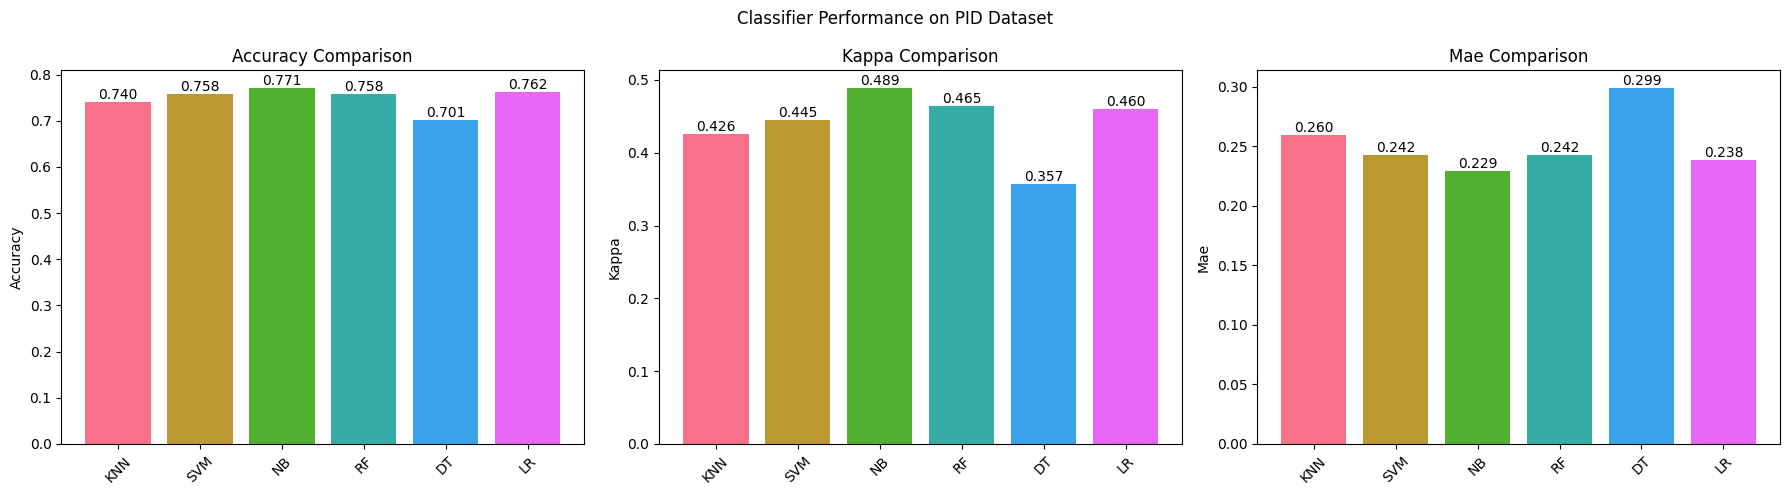

<ipython-input-6-68d6c68ce75c>:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=selected_names, ax=axes[i], palette='Blues_d')
<ipython-input-6-68d6c68ce75c>:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=selected_names, ax=axes[i], palette='Blues_d')


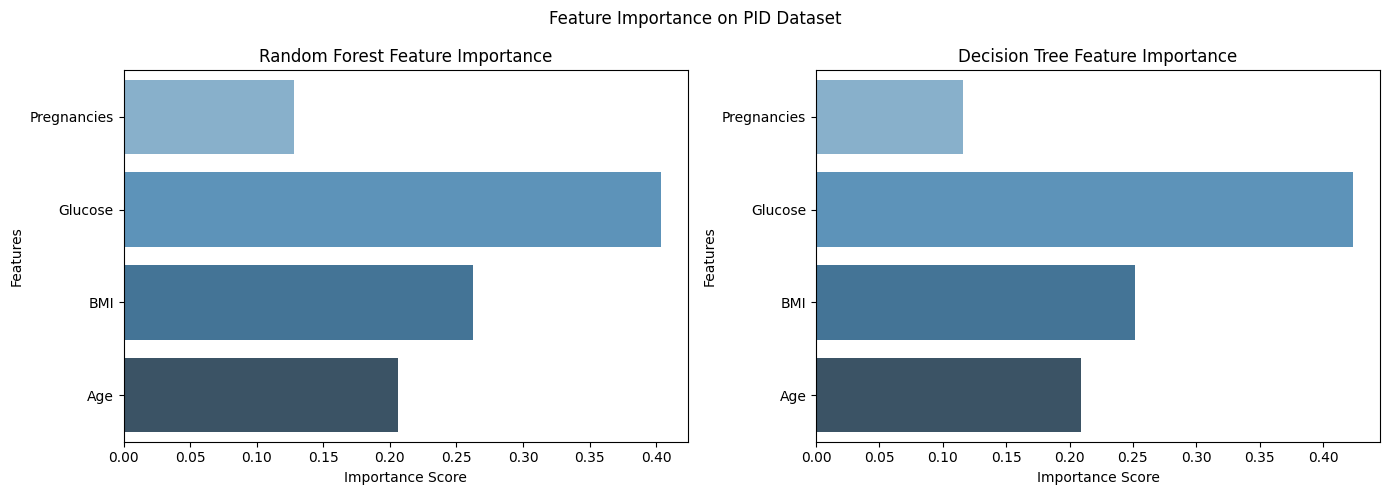

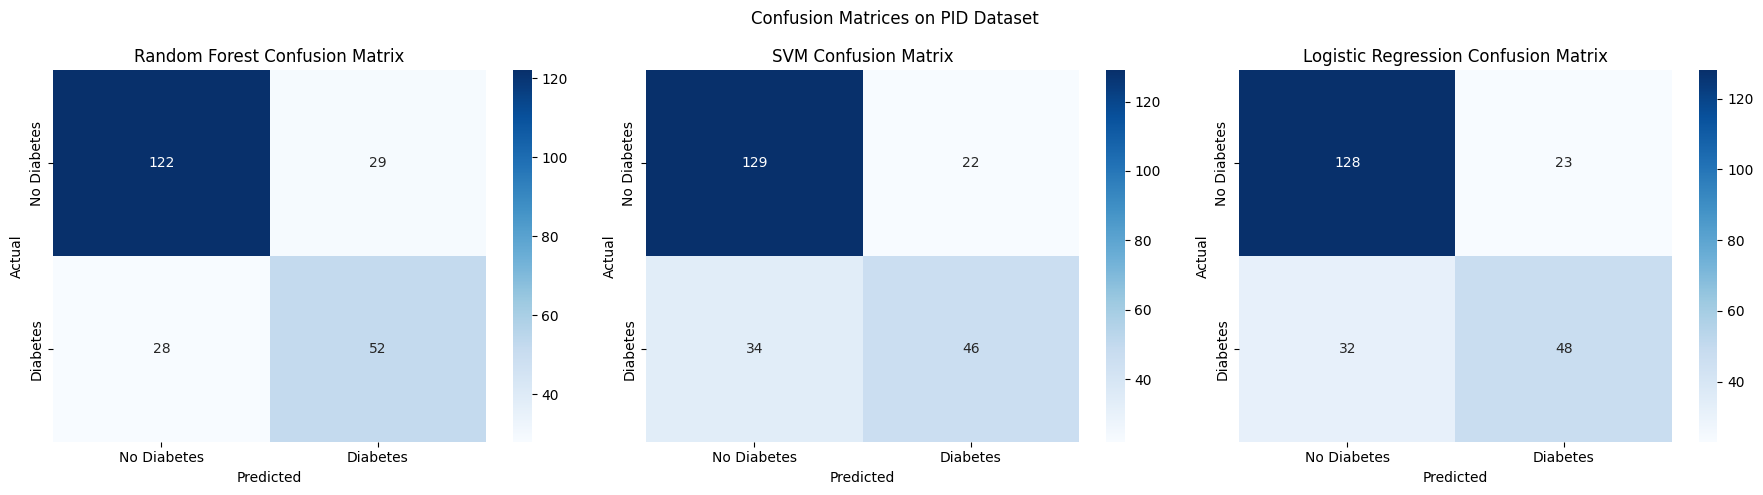


Running analysis for HFD dataset...


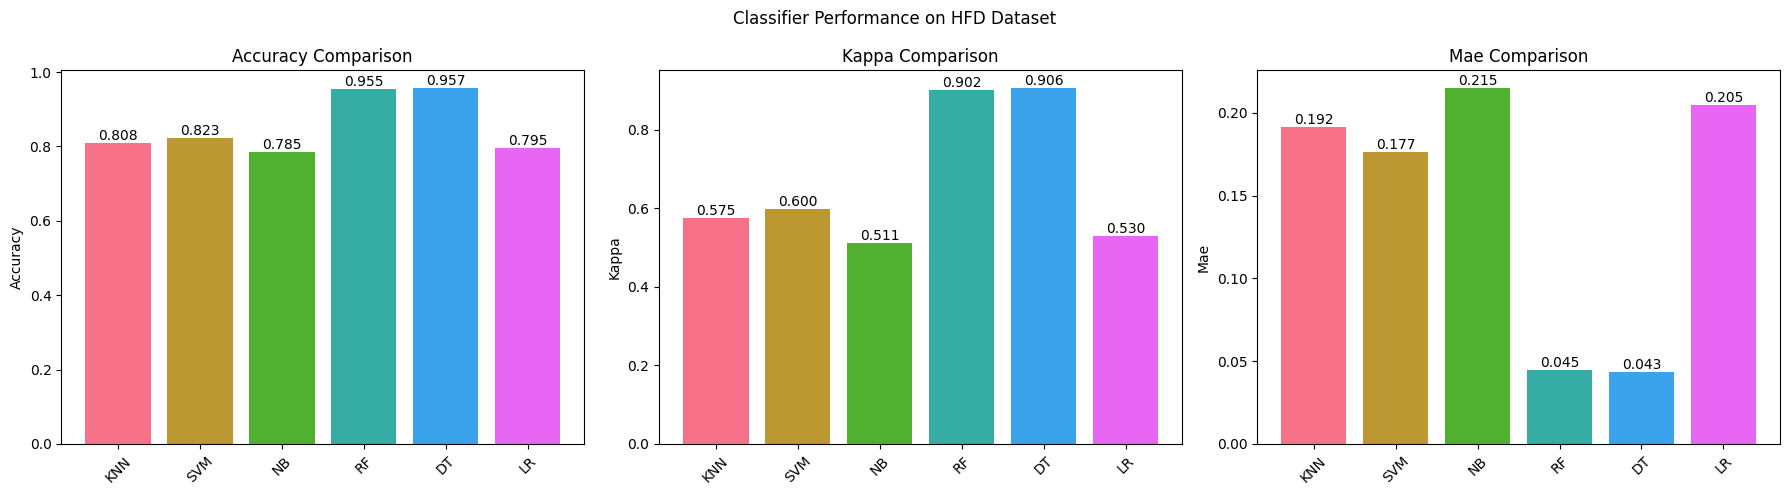

<ipython-input-6-68d6c68ce75c>:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=selected_names, ax=axes[i], palette='Blues_d')
<ipython-input-6-68d6c68ce75c>:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=selected_names, ax=axes[i], palette='Blues_d')


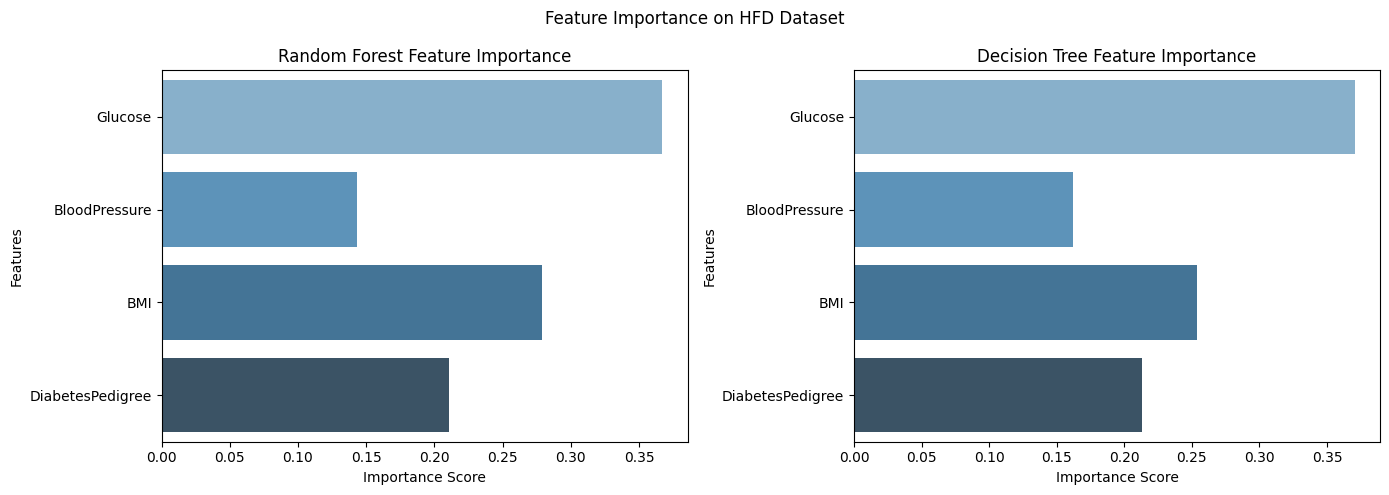

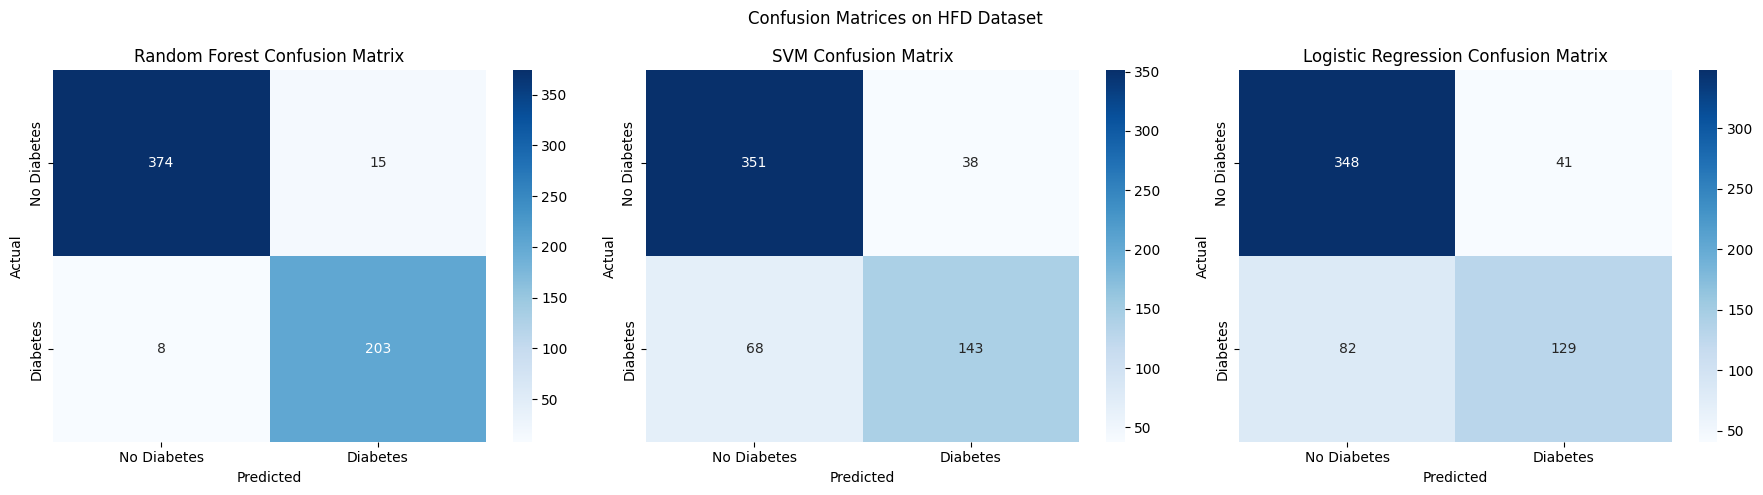

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

class DiabetesClassifierVisual(DiabetesClassifier):
    def plot_performance_comparison(self, results, dataset_name):
        """Plot comparison of classifier performance"""
        metrics = ['accuracy', 'kappa', 'mae']
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        for i, metric in enumerate(metrics):
            values = [results[clf][metric] for clf in results]
            axes[i].bar(results.keys(), values, color=sns.color_palette("husl", 6))
            axes[i].set_title(f'{metric.capitalize()} Comparison')
            axes[i].set_ylabel(metric.capitalize())
            axes[i].tick_params(axis='x', rotation=45)

            # Add value labels
            for j, v in enumerate(values):
                axes[i].text(j, v, f"{v:.3f}", ha='center', va='bottom')

        plt.suptitle(f'Classifier Performance on {dataset_name} Dataset')
        plt.tight_layout()
        plt.savefig(f'{dataset_name}_performance_comparison.png')
        plt.show()

    def plot_feature_importance(self, X_train, y_train, selected_features, dataset_name):
        """Plot feature importance for tree-based models"""
        # Get feature names
        feature_names = [
            'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
            'Insulin', 'BMI', 'Age', 'DiabetesPedigree'
        ]
        selected_names = [feature_names[i-1] for i in selected_features]  # 1-based to 0-based

        # Train models
        rf = RandomForestClassifier(n_estimators=100).fit(X_train, y_train)
        dt = DecisionTreeClassifier().fit(X_train, y_train)

        # Get importances
        rf_importances = rf.feature_importances_
        dt_importances = dt.feature_importances_

        # Plot
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        for i, (importances, model_name) in enumerate(zip(
            [rf_importances, dt_importances],
            ['Random Forest', 'Decision Tree']
        )):
            sns.barplot(x=importances, y=selected_names, ax=axes[i], palette='Blues_d')
            axes[i].set_title(f'{model_name} Feature Importance')
            axes[i].set_xlabel('Importance Score')
            axes[i].set_ylabel('Features')

        plt.suptitle(f'Feature Importance on {dataset_name} Dataset')
        plt.tight_layout()
        plt.savefig(f'{dataset_name}_feature_importance.png')
        plt.show()

    def plot_confusion_matrices(self, X_train, X_test, y_train, y_test, selected_features, dataset_name):
        """Plot confusion matrices for top classifiers"""
        feature_idx = [f-1 for f in selected_features]
        X_train_selected = X_train[:, feature_idx]
        X_test_selected = X_test[:, feature_idx]

        # Train models
        models = {
            'Random Forest': RandomForestClassifier(n_estimators=100),
            'SVM': SVC(),
            'Logistic Regression': LogisticRegression(max_iter=1000)
        }

        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        for ax, (name, model) in zip(axes, models.items()):
            model.fit(X_train_selected, y_train)
            y_pred = model.predict(X_test_selected)
            cm = confusion_matrix(y_test, y_pred)

            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                       xticklabels=['No Diabetes', 'Diabetes'],
                       yticklabels=['No Diabetes', 'Diabetes'])
            ax.set_title(f'{name} Confusion Matrix')
            ax.set_xlabel('Predicted')
            ax.set_ylabel('Actual')

        plt.suptitle(f'Confusion Matrices on {dataset_name} Dataset')
        plt.tight_layout()
        plt.savefig(f'{dataset_name}_confusion_matrices.png')
        plt.show()

    def run_full_experiment_with_plots(self, dataset_path, dataset_name, selected_features):
        """Enhanced experiment with visualizations"""
        # Load data
        X, y = self.load_data(dataset_path)
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

        # Evaluate classifiers
        results = self.evaluate_classifiers(X_train, X_test, y_train, y_test, selected_features)

        # Generate plots
        self.plot_performance_comparison(results, dataset_name)

        # Get 0-based feature indices for plotting
        feature_idx = [f-1 for f in selected_features]
        X_train_selected = X_train[:, feature_idx]

        self.plot_feature_importance(X_train_selected, y_train, selected_features, dataset_name)
        self.plot_confusion_matrices(X_train, X_test, y_train, y_test, selected_features, dataset_name)

        return results

if __name__ == "__main__":
    # Initialize visual classifier
    visual_classifier = DiabetesClassifierVisual()

    # Dataset configurations
    experiments = [
        {'name': 'PID', 'path': 'diabetes.csv', 'features': [1, 2, 6, 7]},
        {'name': 'HFD', 'path': 'diabetes2.csv', 'features': [2, 3, 6, 8]}
    ]

    # Run experiments with visualizations
    for exp in experiments:
        print(f"\nRunning analysis for {exp['name']} dataset...")
        results = visual_classifier.run_full_experiment_with_plots(
            exp['path'], exp['name'], exp['features']
        )